In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm

In [2]:
width=4
gap = 2
num_iters = 50

resize_wid=1024
rw_div2 = int(resize_wid/2)

inner_wid=100
indiv2 = int(inner_wid/2)

In [5]:
import jax as jx

In [73]:
def sig_val_thresholding(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)): ##Sigma[Sigma < thresh] = 0
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

def sig_val_thresholding_fast(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    thresh = Sigma.max() * zero_thresh
    S_reduced = np.where(Sigma > thresh, Sigma, 0)
    return U, S_reduced, Vh

def sig_val_thresholding_jax(data, zero_thresh):
    U, Sigma, Vh = jx.numpy.linalg.svd(data, full_matrices=False)
    print(len(Sigma))
    thresh = Sigma.max() * zero_thresh
    S_reduced = np.where(Sigma > thresh, Sigma, 0)
    return U, S_reduced, Vh

In [9]:
zte_radial_kspacedlt, zte_radial_coordsdlt, zte_radial_kspacezero, zte_radial_coordszero, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=(gap), undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacezero, coords=zte_radial_coordszero)

cartesian_kspace_enl = asm.zero_padding(cart_kspace=cartesian_zte, resize_x=resize_wid, resize_y=resize_wid)

inner_region, inner_mask, start, end = asm.inner_portion(enlarged_kspace=cartesian_kspace_enl, inner_sidelen=inner_wid)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


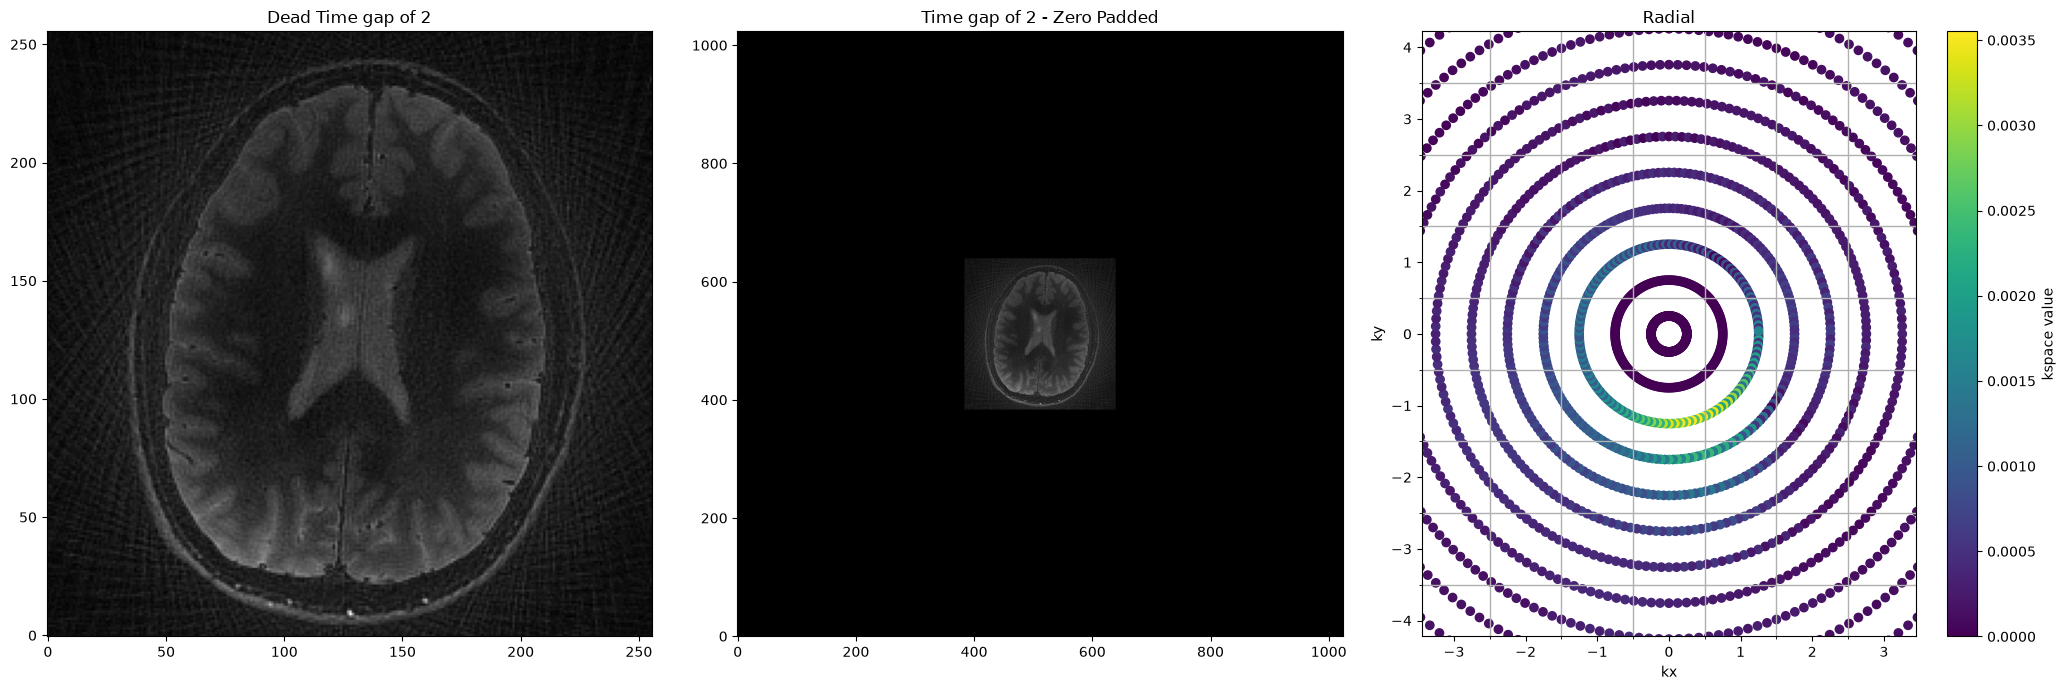

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(21, 7))

im_grid1 = sp.ifft(cartesian_zte, axes=(-2, -1))
im_1 = np.sum(np.abs(im_grid1)**2, axis=0)**0.5
ax[0].imshow(im_1, cmap='gray', origin='lower')
ax[0].set_title(f'Dead Time gap of {gap}')

im_grid2 = sp.ifft(cartesian_kspace_enl, axes=(-2, -1))
im_2 = np.sum(np.abs(im_grid2)**2, axis=0)**0.5
ax[1].imshow(im_2, cmap='gray', origin='lower')
ax[1].set_title(f'Time gap of {gap} - Zero Padded')


zte_radial_coordszero = zte_radial_coordszero.reshape(-1, 2)

im2 = ax[2].scatter(zte_radial_coordszero[:, 0],zte_radial_coordszero[:, 1], c=np.abs(zte_radial_kspacezero[0]), cmap='viridis')
fig.colorbar(im2, ax=ax[2], label='kspace value')
ax[2].set_title('Radial')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].set_xlim(0 - 3, 0 + 3)
ax[2].set_ylim(0 - 3, 0 + 3)

plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


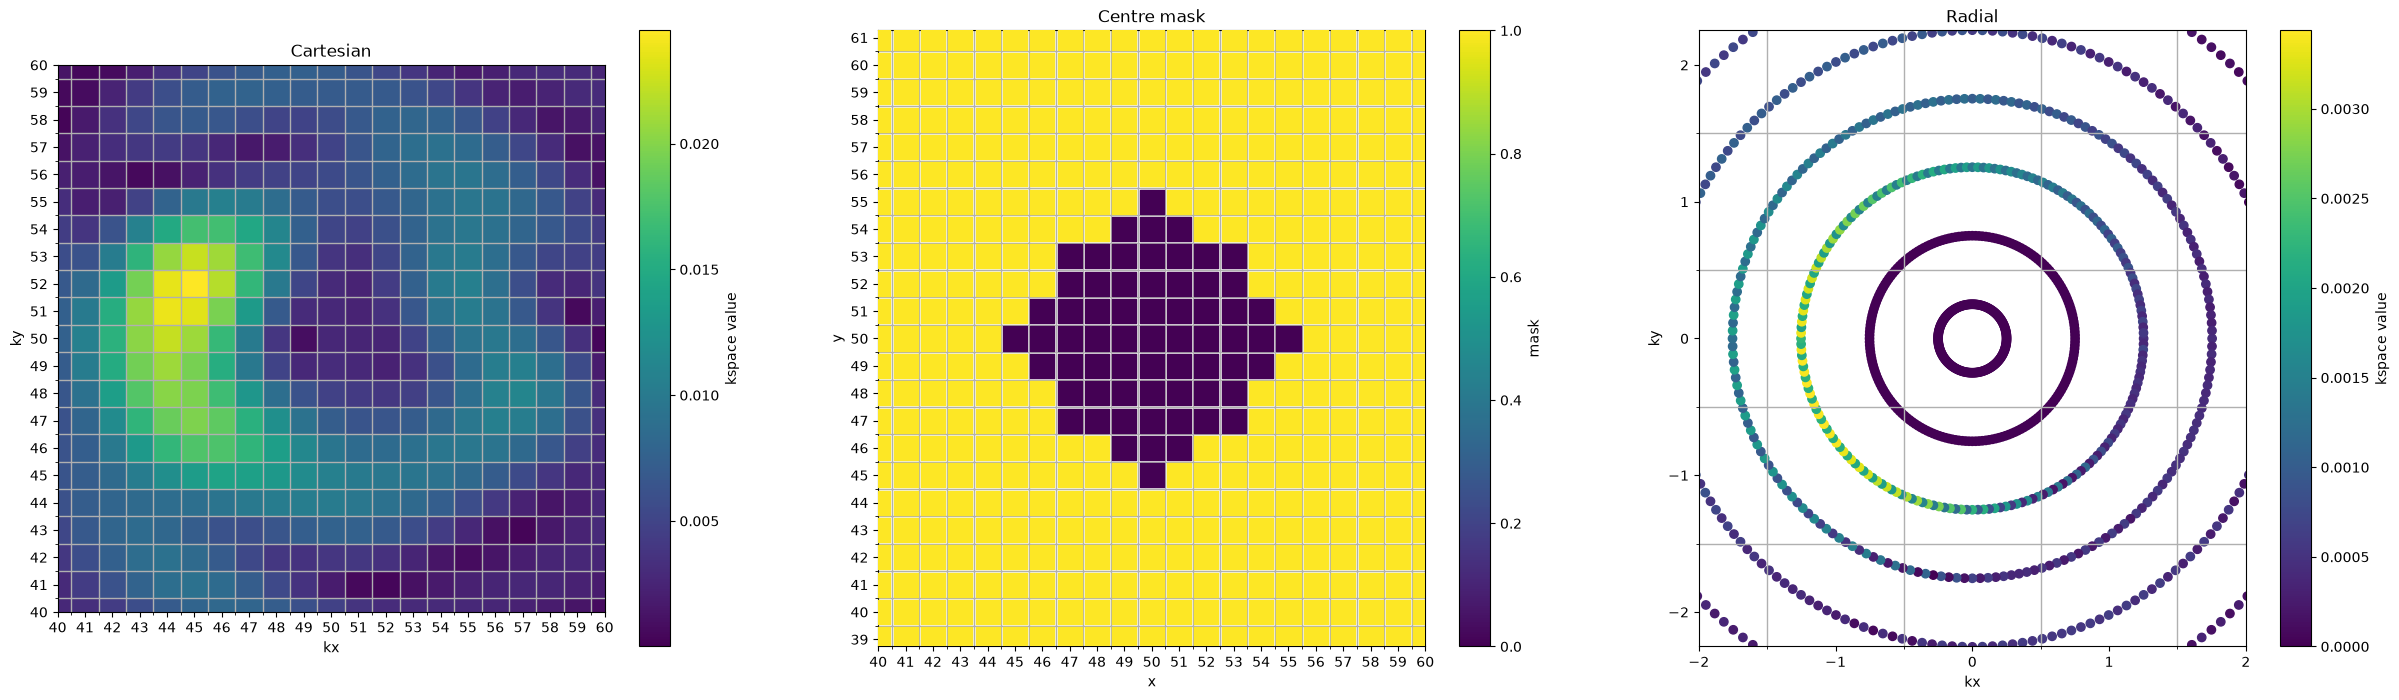

In [11]:
cy, cx = inner_wid // 2, inner_wid // 2
r = 4  # radius in pixels; adjust to cover the gap
yy, xx = np.ogrid[:inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

mask[(cx-5):(cx+6), cy] = False
mask[(cx), (cy-5):(cy+6)] = False


masked_inner = inner_region.copy()
masked_inner[:,~mask] = 0

inner_removed = inner_region.copy()
inner_removed[:,mask] = 0

totalwid = 1024
totaldiv = totalwid // 2

mask2 = np.ones((totalwid, totalwid), dtype=bool)

mask2[(indiv2-3):(indiv2+3), indiv2:indiv2+1] = False
mask2[(indiv2), (indiv2-2):(indiv2+3)] = False


asm.plot_mask(inner_region, mask=mask, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


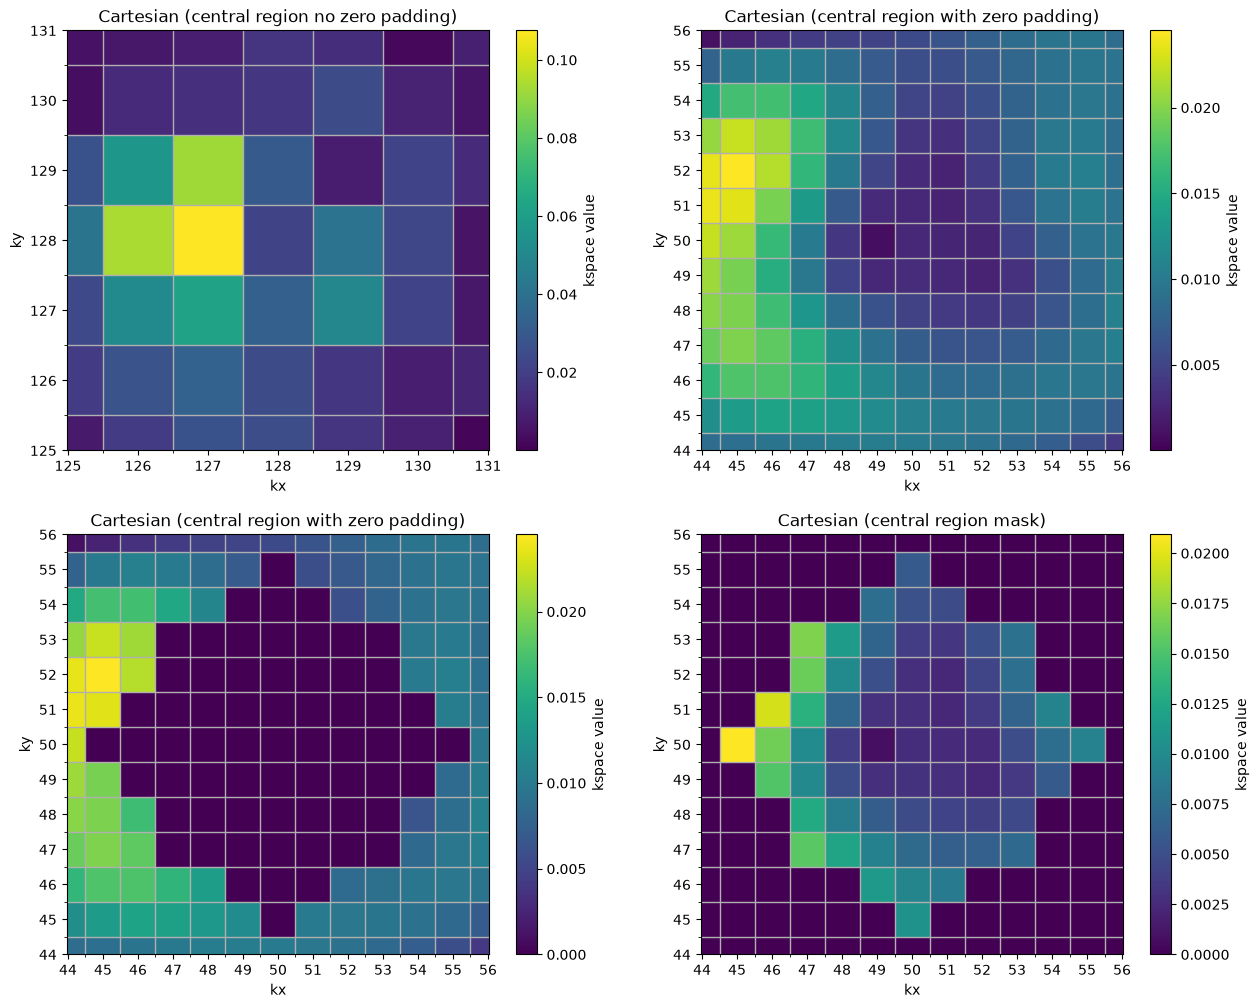

In [72]:
all_coords = zte_radial_coordsdlt.reshape(-1, 2)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))


im_new = ax[0, 0].imshow(np.abs(cartesian_zte[0]), cmap='viridis', origin='lower')
fig.colorbar(im_new, ax=ax[0, 0], label='kspace value')

ax[0, 0].set_title('Cartesian (central region no zero padding)')
ax[0, 0].set_xlabel('kx')
ax[0, 0].set_ylabel('ky')
ax[0, 0].axis('equal')
ax[0, 0].set_xlim(256/2 - 3,256/2 + 3)
ax[0, 0].set_ylim(256/2 - 3,256/2 + 3)
ax[0, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0, 0].grid(visible=True, which='minor', linewidth=1)
ax[0, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0, 0].yaxis.set_major_locator(plt.MultipleLocator(1))


im = ax[0, 1].imshow(np.abs(inner_region[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0, 1], label='kspace value')

ax[0, 1].set_title('Cartesian (central region with zero padding)')
ax[0, 1].set_xlabel('kx')
ax[0, 1].set_ylabel('ky')
ax[0, 1].axis('equal')
ax[0, 1].set_xlim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[0, 1].set_ylim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[0, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0, 1].grid(visible=True, which='minor', linewidth=1)
ax[0, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0, 1].yaxis.set_major_locator(plt.MultipleLocator(1))


im = ax[1, 0].imshow(np.abs(masked_inner[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1, 0], label='kspace value')

ax[1, 0].set_title('Cartesian (central region with zero padding)')
ax[1, 0].set_xlabel('kx')
ax[1, 0].set_ylabel('ky')
ax[1, 0].axis('equal')
ax[1, 0].set_xlim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[1, 0].set_ylim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[1, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].grid(visible=True, which='minor', linewidth=1)
ax[1, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 0].yaxis.set_major_locator(plt.MultipleLocator(1))


im = ax[1, 1].imshow(np.abs(inner_removed[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1, 1], label='kspace value')

ax[1, 1].set_title('Cartesian (central region mask)')
ax[1, 1].set_xlabel('kx')
ax[1, 1].set_ylabel('ky')
ax[1, 1].axis('equal')
ax[1, 1].set_xlim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[1, 1].set_ylim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].grid(visible=True, which='minor', linewidth=1)
ax[1, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 1].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.show()

In [13]:
def LORAKS_loop(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask):
    ksp_forhankel = cartesian_inputkspace.copy()
    iter_count = 0
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
        U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh

        kspace_cart_coils_recon = asm.hankel_H_averaged(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        for coil in range(ksp_forhankel.shape[0]):
            kspace_cart_coils_consistent[coil, dtg_mask] = cartesian_inputkspace[coil, dtg_mask]
        ksp_forhankel = kspace_cart_coils_consistent.copy()
        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    return(output_kspace)

## Storing the inner kspace values to visualise convergence

1. At each iteration take the array and flatten
2. Take the square root of the sum of all the squared values and store
3. For each iteration, calculate the relative change by subtracting k from k-1 then dividing by k-1

Note:
1. Likely quicker to prebuild the df
2. Likely quicker to calculate

In [17]:
#post_loop_kspace = LORAKS_loop(n_iters=num_iters, window_size=5, zero_thresh=0.2, cartesian_inputkspace=inner_region, dtg_mask=mask)

In [74]:
import time
num_iters = 5
ksp_forhankel = inner_region.copy()

deltas = []
k_prev = None
window_size = 5

timings = {'hankel': [], 'svt': [], 'hankel_H': [], 'masking': []}

iter_count = 0
while iter_count < num_iters:
    t0 = time.perf_counter()
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
    t1 = time.perf_counter()
    timings['hankel'].append(t1 - t0)

    U, S_reduced, Vh = sig_val_thresholding_jax(data=hankel_matrix, zero_thresh=0.2)
    t2 = time.perf_counter()
    timings['svt'].append(t2 - t1)

    data_recon = np.asarray((U * S_reduced) @ Vh)

    kspace_cart_coils_recon = asm.hankel_H_averaged(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
    t3 = time.perf_counter()
    timings['hankel_H'].append(t3 - t2)

    kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

    for coil in range(ksp_forhankel.shape[0]):
        kspace_cart_coils_consistent[coil, mask] = inner_region[coil, mask]
    ksp_forhankel = kspace_cart_coils_consistent.copy()
    t4 = time.perf_counter()
    timings['masking'].append(t4 - t3)

    vec = ksp_forhankel[:, ~mask]

    if k_prev is not None:
        deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
    k_prev = vec.copy()

    iter_count += 1

output_kspace = ksp_forhankel.copy()

300
300
300
300
300


hankel: total across 100 iterations =5.8147s, mean=0.0581s
svt: total across 100 iterations =39.8600s, mean=0.3986s
hankel_H: total across 100 iterations =38.0655s, mean=0.3807s
masking: total across 100 iterations =0.1433s, mean=0.0014s


Text(0, 0.5, 'relative change')

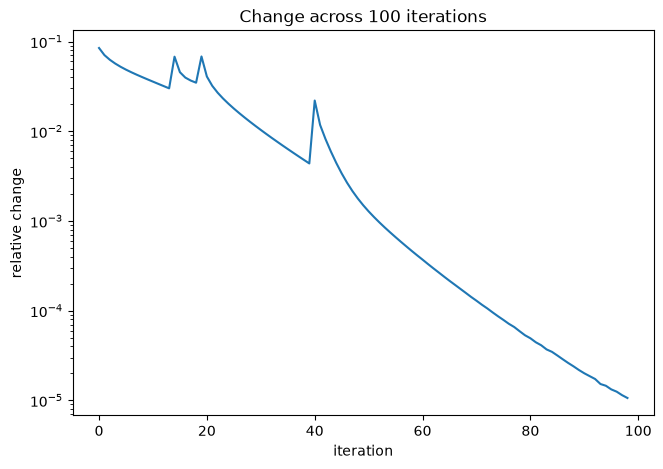

In [67]:
for k, v in timings.items():
    print(f"{k}: total across {num_iters} iterations ={sum(v):.4f}s, mean={np.mean(v):.4f}s")

plt.figure(figsize=(7.5,5))
plt.semilogy(deltas)
plt.title(f'Change across {num_iters} iterations')
plt.xlabel("iteration")
plt.ylabel("relative change")

In [68]:
recombined = asm.jigsaw(output_kspace=output_kspace, isolation_mask = inner_mask, start=start, end=end, enlarged_kspace=cartesian_kspace_enl)
cartesian_kspace_rebuild = asm.zero_padding(recombined, 256,256)
post_loop_kspace = output_kspace.copy()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


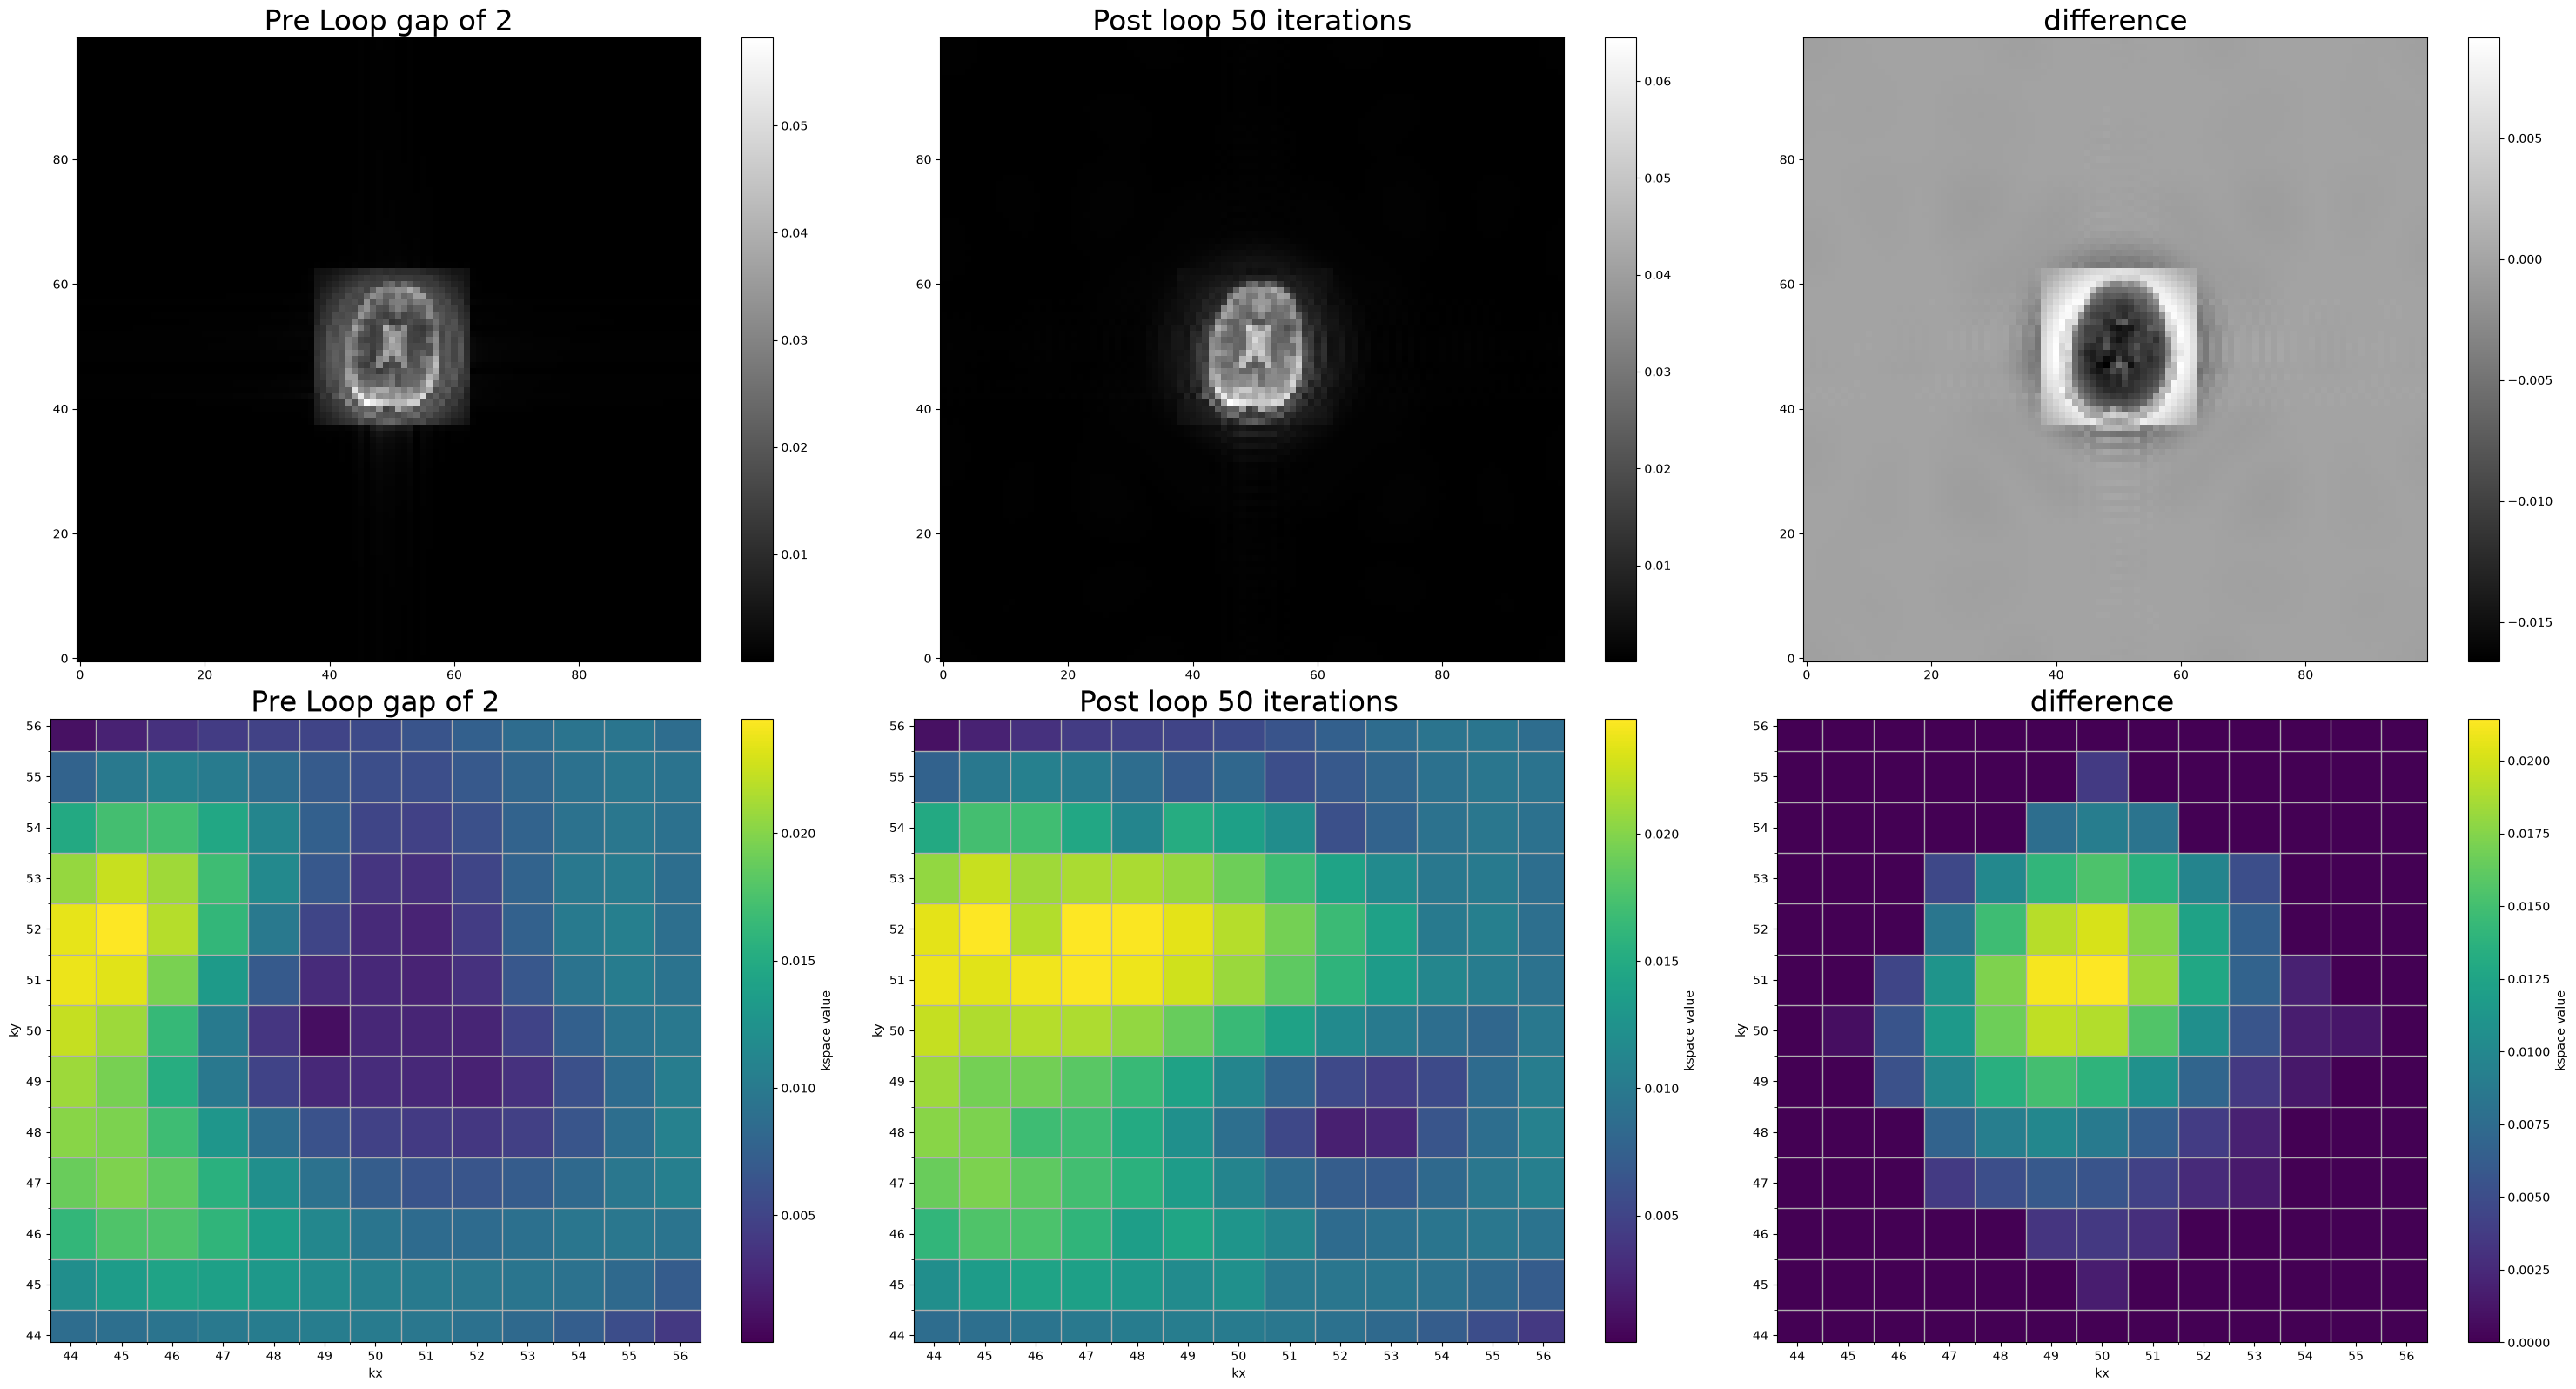

In [69]:
zte_radial_kspace1, zte_radial_coords1 = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=1, undersampling_factor=1)
dcf1 = (zte_radial_coords1[...,0]**2 + zte_radial_coords1[...,1]**2)**0.5
im_grid = sp.nufft_adjoint(zte_radial_kspace1* dcf1, zte_radial_coords1)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(30, 16))

# Row 0: image-space magnitude
im1 = np.sum(np.abs(sp.ifft(inner_region))**2, axis=0)**0.5
p0 = ax[0, 0].imshow(im1, cmap='gray', origin='lower')
ax[0, 0].set_title(f'Pre Loop gap of {gap}', fontsize=24)
fig.colorbar(p0, ax=ax[0, 0])

im2 = np.sum(np.abs(sp.ifft(post_loop_kspace))**2, axis=0)**0.5
p1 = ax[0, 1].imshow(im2, cmap='gray', origin='lower')
ax[0, 1].set_title(f'Post loop {50} iterations', fontsize=24)
fig.colorbar(p1, ax=ax[0, 1])

p2 = ax[0, 2].imshow(im1-im2, cmap='gray', origin='lower')
ax[0, 2].set_title('difference', fontsize=24)
fig.colorbar(p2, ax=ax[0, 2])

# Row 1: k-space
all_coords = zte_radial_coordsdlt.reshape(-1, 2)

im = ax[1, 0].imshow(np.abs(inner_region[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1, 0], label='kspace value')
ax[1, 0].set_title(f'Pre Loop gap of {gap}', fontsize=24)
ax[1, 0].set_xlabel('kx')
ax[1, 0].set_ylabel('ky')
ax[1, 0].axis('equal')
ax[1, 0].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 0].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].grid(visible=True, which='minor', linewidth=1)
ax[1, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 0].yaxis.set_major_locator(plt.MultipleLocator(1))

im1k = ax[1, 1].imshow(np.abs(post_loop_kspace[0]), cmap='viridis', origin='lower')
fig.colorbar(im1k, ax=ax[1, 1], label='kspace value')
ax[1, 1].set_title(f'Post loop {50} iterations', fontsize=24)
ax[1, 1].set_xlabel('kx')
ax[1, 1].set_ylabel('ky')
ax[1, 1].axis('equal')
ax[1, 1].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 1].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].grid(visible=True, which='minor', linewidth=1)
ax[1, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 1].yaxis.set_major_locator(plt.MultipleLocator(1))

diff = inner_region - post_loop_kspace

im2k = ax[1, 2].imshow(np.abs(diff[0]), cmap='viridis', origin='lower')
fig.colorbar(im2k, ax=ax[1, 2], label='kspace value')
ax[1, 2].set_title('difference', fontsize=24)
ax[1, 2].set_xlabel('kx')
ax[1, 2].set_ylabel('ky')
ax[1, 2].axis('equal')
ax[1, 2].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 2].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].grid(visible=True, which='minor', linewidth=1)
ax[1, 2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 2].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout()
plt.show()

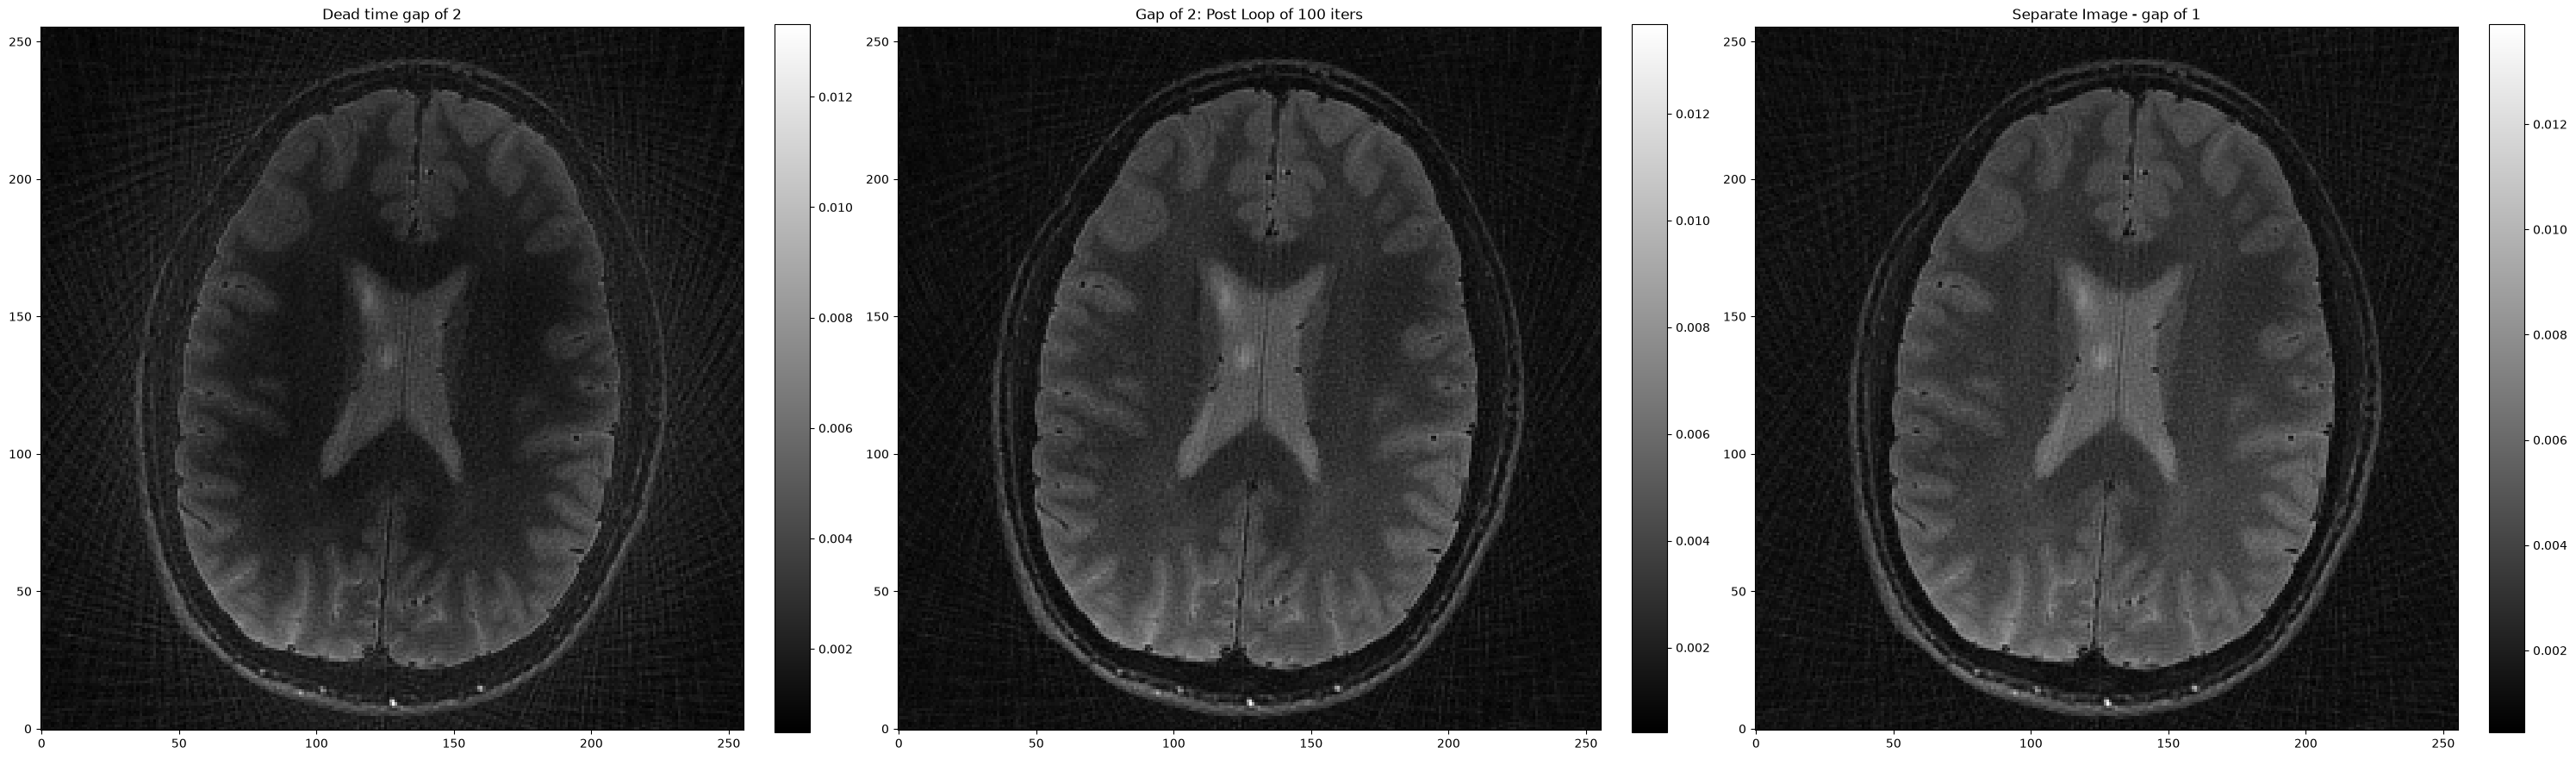

In [70]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 16))


im_grid1 = sp.ifft(cartesian_zte, axes=(-2, -1))
im_1 = np.sum(np.abs(im_grid1)**2, axis=0)**0.5
p0 = ax[0].imshow(im_1, cmap='gray', origin='lower')
ax[0].set_title(f'Dead time gap of {gap}')
fig.colorbar(p0, ax=ax[0], fraction=0.046, pad=0.04)

im_grid2 = sp.ifft(cartesian_kspace_rebuild, axes=(-2, -1))
im_2 = np.sum(np.abs(im_grid2)**2, axis=0)**0.5
p1 = ax[1].imshow(im_2, cmap='gray', origin='lower')
ax[1].set_title(f'Gap of 2: Post Loop of {num_iters} iters')
fig.colorbar(p1, ax=ax[1], fraction=0.046, pad=0.04)

img_3 = np.sum(np.abs(im_grid)**2, axis=0)**0.5
p2 = ax[2].imshow(img_3, cmap='gray', origin='lower')
ax[2].set_title('Separate Image - gap of 1')
fig.colorbar(p2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()